# Stage 1b: Provisioning Classification & Recommendation Engine
**Cloud Resource Optimisation Thesis — Frankfurt School of Finance and Management**  
**Author:** Prarthana Govindaraj  
**Date:** May 2026  

---

## Note on Data Pipeline
This notebook incorporates Pinki's corrections:
- Column mapping fix: cpu_max and cpu_avg were swapped in the raw batch_instance file
- Join fix: 4-key join on job_name + task_name + instance_name + task_id before aggregation

## Structure
- Section 0: Setup and Data Load (with Pinki's fixes)
- Section 1: Target Variable Creation
- Section 2: Feature Engineering
- Section 3: Exploratory Deep Dive
- Section 4: Train/Test Split
- Section 5: Baseline Model (Logistic Regression)
- Section 6: Main Model (Random Forest)
- Section 7: Error Analysis
- Section 8: Correction Factor & Recommendation Engine
- Section 9: Final Summary

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


---
## Section 0: Setup and Data Load

### Pinki's Correction 1 — Column Mapping
In the raw batch_instance file, cpu_max and cpu_avg are swapped.
Correct column order: instance_name, task_name, job_name, task_id,
start_time, status, seq_no, total_seq_no, cpu_max, cpu_avg, mem_max, mem_avg

### Pinki's Correction 2 — Join Key
Joining only on job_name creates a cross join when one job has multiple tasks.
Correct approach: join on all 4 keys — job_name + task_name + instance_name + task_id
then aggregate to job level.

In [22]:
BASE_DIR      = Path('/Users/prarthanagovindaraj/Desktop/Cloud_Resource_Optimisation_thesis')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'

bt = pd.read_csv(PROCESSED_DIR / 'batch_task_corrected.csv')
bi = pd.read_csv(PROCESSED_DIR / 'batch_instance_corrected.csv')

# Force correct column names regardless of what the file has
bt.columns = ['task_name', 'instance_name', 'job_name', 'task_id',
               'start_time', 'status', 'plan_cpu', 'plan_mem']

bi.columns = ['instance_name', 'task_name', 'job_name', 'task_id',
               'start_time', 'status', 'seq_no', 'total_seq_no',
               'cpu_max', 'cpu_avg', 'mem_max', 'mem_avg']

print(f"batch_task:     {bt.shape[0]:,} rows x {bt.shape[1]} columns")
print(f"batch_instance: {bi.shape[0]:,} rows x {bi.shape[1]} columns")
print(f"\nFirst 3 rows of batch_task:")
print(bt.head(3))
print(f"\nFirst 3 rows of batch_instance:")
print(bi.head(3))
print(f"\nSanity check — cpu_max should be >= cpu_avg in all rows:")
print(f"  Rows where cpu_max < cpu_avg: {(bi['cpu_max'] < bi['cpu_avg']).sum():,}")

batch_task:     80,553 rows x 8 columns
batch_instance: 16,094,656 rows x 12 columns

First 3 rows of batch_task:
   task_name  instance_name  job_name  task_id  start_time      status  \
0       6459           6524         3        4       15740  Terminated   
1       6457           6533         3        5           1  Terminated   
2       6036           6046         4        7         393     Waiting   

   plan_cpu  plan_mem  
0      50.0  0.007957  
1      50.0  0.004395  
2       NaN       NaN  

First 3 rows of batch_instance:
   instance_name  task_name  job_name  task_id  start_time      status  \
0          41562      41618     120.0    686.0       299.0  Terminated   
1          41561      41619     120.0    686.0      1279.0  Terminated   
2          41562      41617     120.0    686.0       828.0  Terminated   

   seq_no  total_seq_no  cpu_max  cpu_avg  mem_max  mem_avg  
0       1             1     1.50     0.29      NaN      NaN  
1       1             1     0.89     0.

In [23]:
print(f"batch_task rows:     {len(bt):,}")
print(f"batch_instance rows: {len(bi):,}")
print(f"\nUnique jobs in batch_task:     {bt['job_name'].nunique():,}")
print(f"Unique jobs in batch_instance: {bi['job_name'].nunique():,}")

print(f"\nbatch_instance violations (cpu_max < cpu_avg): {(bi['cpu_max'] < bi['cpu_avg']).sum():,}")
print(f"As % of total: {(bi['cpu_max'] < bi['cpu_avg']).sum() / len(bi) * 100:.4f}%")

print(f"\nbatch_task status distribution:")
print(bt['status'].value_counts())

print(f"\nbatch_instance status distribution:")
print(bi['status'].value_counts())

batch_task rows:     80,553
batch_instance rows: 16,094,656

Unique jobs in batch_task:     12,951
Unique jobs in batch_instance: 12,951

batch_instance violations (cpu_max < cpu_avg): 1,973
As % of total: 0.0123%

batch_task status distribution:
status
Terminated    67013
Waiting        8847
Running        3567
Failed         1126
Name: count, dtype: int64

batch_instance status distribution:
status
Terminated     13707867
Waiting         1268982
Running          835194
Failed           209168
Ready             67618
Interrupted        5827
Name: count, dtype: int64


In [25]:
print("=" * 70)
print("APPLYING PINKI'S 4-KEY JOIN AND AGGREGATION")
print("=" * 70)

bt_terminated = bt[bt['status'] == 'Terminated'].copy()
bi_terminated = bi[bi['status'] == 'Terminated'].copy()

print(f"\nTerminated records:")
print(f"  batch_task:     {len(bt_terminated):,}")
print(f"  batch_instance: {len(bi_terminated):,}")

bt_terminated['plan_cpu_cores'] = bt_terminated['plan_cpu'] / 100

bt_agg_job = bt_terminated.groupby('job_name').agg(
    plan_cpu_cores=('plan_cpu_cores', 'sum'),
    task_count=('task_name', 'nunique')
).reset_index()

bi_agg_job = bi_terminated.groupby('job_name').agg(
    cpu_avg_peak=('cpu_avg', 'max'),
    cpu_max_peak=('cpu_max', 'max'),
    instance_count=('instance_name', 'count'),
    cpu_avg_mean=('cpu_avg', 'mean'),
    cpu_avg_std=('cpu_avg', 'std'),
    cpu_avg_max=('cpu_avg', 'max')
).reset_index()

merged_job = pd.merge(bt_agg_job, bi_agg_job, on='job_name', how='inner')
merged_job['util_ratio_avg']  = merged_job['cpu_avg_peak'] / merged_job['plan_cpu_cores']
merged_job['util_ratio_peak'] = merged_job['cpu_max_peak'] / merged_job['plan_cpu_cores']

merged_job = merged_job.replace([np.inf, -np.inf], np.nan)
merged_job = merged_job.dropna(subset=['plan_cpu_cores', 'cpu_avg_peak', 'cpu_max_peak'])
merged_job = merged_job[merged_job['plan_cpu_cores'] > 0]

merged_clean = merged_job.copy()

print(f"\nFinal dataset: {len(merged_clean):,} jobs")
print(f"\nSample:")
print(merged_clean[['job_name', 'plan_cpu_cores', 'cpu_avg_peak', 'cpu_max_peak',
                     'util_ratio_avg', 'util_ratio_peak']].head(5))
print(f"\nSanity check — cpu_max_peak should be >= cpu_avg_peak:")
violations = (merged_clean['cpu_max_peak'] < merged_clean['cpu_avg_peak']).sum()
print(f"  Violations: {violations:,}")
print(f"\nUnique jobs in batch_task (terminated):     {bt_terminated['job_name'].nunique():,}")
print(f"Unique jobs in batch_instance (terminated): {bi_terminated['job_name'].nunique():,}")
print(f"Jobs in merged_clean:                        {len(merged_clean):,}")

APPLYING PINKI'S 4-KEY JOIN AND AGGREGATION

Terminated records:
  batch_task:     67,013
  batch_instance: 13,707,867

Final dataset: 11,644 jobs

Sample:
   job_name  plan_cpu_cores  cpu_avg_peak  cpu_max_peak  util_ratio_avg  \
0         1             1.0          0.82          2.00            0.82   
1         2             1.0          1.04          3.00            1.04   
2         3             1.0          1.26          3.00            1.26   
3         5             1.0          0.99          2.03            0.99   
4         6             1.0          0.33          0.79            0.33   

   util_ratio_peak  
0             2.00  
1             3.00  
2             3.00  
3             2.03  
4             0.79  

Sanity check — cpu_max_peak should be >= cpu_avg_peak:
  Violations: 0

Unique jobs in batch_task (terminated):     11,644
Unique jobs in batch_instance (terminated): 11,807
Jobs in merged_clean:                        11,644


---
## Section 1: Target Variable Creation

| Class | Condition | Meaning |
|-------|-----------|---------|
| `severely_under` | util_ratio_peak >= 1.5 | Using >150% of requested |
| `under` | 1.0 <= util_ratio_peak < 1.5 | Using 100-150% of requested |
| `efficient` | 0.5 <= util_ratio_peak < 1.0 | Using 50-100% |
| `over` | util_ratio_peak < 0.5 | Using <50% — wasteful |

In [26]:
def classify_provisioning(ratio):
    if ratio >= 1.5:
        return 'severely_under'
    elif ratio >= 1.0:
        return 'under'
    elif ratio >= 0.5:
        return 'efficient'
    else:
        return 'over'

merged_clean['provisioning_class'] = merged_clean['util_ratio_peak'].apply(classify_provisioning)
merged_clean['is_underprovision'] = (merged_clean['util_ratio_peak'] >= 1.0).astype(int)

print("=" * 60)
print("CLASS DISTRIBUTION (4-class)")
print("=" * 60)
total = len(merged_clean)
for cls in ['severely_under', 'under', 'efficient', 'over']:
    count = (merged_clean['provisioning_class'] == cls).sum()
    print(f"  {cls:<20}: {count:>6,}  ({count/total*100:.1f}%)")

print(f"\n{'TOTAL':<20}: {total:>6,}")

print("\n" + "=" * 60)
print("BINARY LABEL DISTRIBUTION")
print("=" * 60)
under_count = merged_clean['is_underprovision'].sum()
not_under   = total - under_count
print(f"  Under-provisioned (1) : {under_count:>6,}  ({under_count/total*100:.1f}%)")
print(f"  Not under-prov.   (0) : {not_under:>6,}  ({not_under/total*100:.1f}%)")

CLASS DISTRIBUTION (4-class)
  severely_under      :  3,225  (27.7%)
  under               :  1,924  (16.5%)
  efficient           :  3,206  (27.5%)
  over                :  3,289  (28.2%)

TOTAL               : 11,644

BINARY LABEL DISTRIBUTION
  Under-provisioned (1) :  5,149  (44.2%)
  Not under-prov.   (0) :  6,495  (55.8%)



SEVERELY_UNDER:
 job_name  plan_cpu_cores  cpu_max_peak  util_ratio_peak provisioning_class
        1             1.0           2.0              2.0     severely_under
        2             1.0           3.0              3.0     severely_under

UNDER:
 job_name  plan_cpu_cores  cpu_max_peak  util_ratio_peak provisioning_class
       21             2.0          2.04             1.02              under
       24             1.0          1.05             1.05              under

EFFICIENT:
 job_name  plan_cpu_cores  cpu_max_peak  util_ratio_peak provisioning_class
        6             1.0          0.79             0.79          efficient
        7             5.0          3.00             0.60          efficient

OVER:
 job_name  plan_cpu_cores  cpu_max_peak  util_ratio_peak provisioning_class
       10             8.0          2.00            0.250               over
       13             6.0          2.19            0.365               over


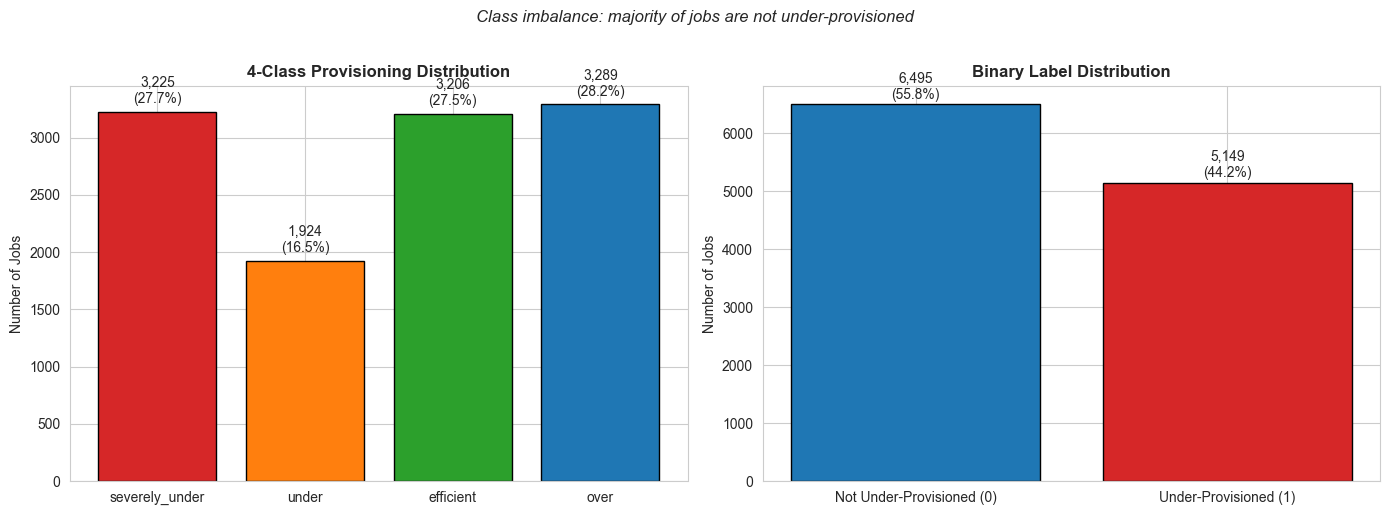


Note: class_weight='balanced' will be used in all models


In [27]:
for cls in ['severely_under', 'under', 'efficient', 'over']:
    sample = merged_clean[merged_clean['provisioning_class'] == cls][
        ['job_name', 'plan_cpu_cores', 'cpu_max_peak', 'util_ratio_peak', 'provisioning_class']
    ].head(2)
    print(f"\n{cls.upper()}:")
    print(sample.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_order = ['severely_under', 'under', 'efficient', 'over']
counts = [merged_clean['provisioning_class'].eq(c).sum() for c in class_order]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

axes[0].bar(class_order, counts, color=colors, edgecolor='black')
axes[0].set_title('4-Class Provisioning Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Jobs')
for bar, count in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({count/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

axes[1].bar(['Not Under-Provisioned (0)', 'Under-Provisioned (1)'],
            [not_under, under_count],
            color=['#1f77b4', '#d62728'], edgecolor='black')
axes[1].set_title('Binary Label Distribution', fontweight='bold')
axes[1].set_ylabel('Number of Jobs')
for bar, count in zip(axes[1].patches, [not_under, under_count]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}\n({count/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

plt.suptitle('Class imbalance: majority of jobs are not under-provisioned',
             fontsize=12, style='italic', y=1.02)
plt.tight_layout()
plt.show()

print("\nNote: class_weight='balanced' will be used in all models")

---
## Section 2: Feature Engineering

Only features known **before the job runs** are used.

**Derived features:**
- `plan_cpu_per_task` — average CPU requested per task
- `instance_to_task_ratio` — instances per task
- `is_multi_task` — binary: more than 1 task?
- `is_large_job` — binary: requests >= 5 cores?
- `cpu_size_bucket_encoded` — integer encoding of size bucket

In [28]:
print("=" * 60)
print("SECTION 2: FEATURE ENGINEERING")
print("=" * 60)

merged_clean['plan_cpu_per_task'] = (
    merged_clean['plan_cpu_cores'] / merged_clean['task_count']
)

merged_clean['instance_to_task_ratio'] = (
    merged_clean['instance_count'] / merged_clean['task_count']
)

merged_clean['is_multi_task'] = (merged_clean['task_count'] > 1).astype(int)

merged_clean['is_large_job'] = (merged_clean['plan_cpu_cores'] >= 5).astype(int)

merged_clean['size_bucket'] = pd.cut(
    merged_clean['plan_cpu_cores'],
    bins=[0, 0.5, 1.0, 2.0, 5.0, 10.0, 1000],
    labels=['Tiny (0-0.5)', 'Small (0.5-1)', 'Medium (1-2)',
            'Large (2-5)', 'XLarge (5-10)', 'Huge (10+)']
)

bucket_order = {
    'Tiny (0-0.5)' : 0,
    'Small (0.5-1)': 1,
    'Medium (1-2)'  : 2,
    'Large (2-5)'   : 3,
    'XLarge (5-10)' : 4,
    'Huge (10+)'    : 5
}

merged_clean['cpu_size_bucket_encoded'] = merged_clean['size_bucket'].map(bucket_order)

FEATURES = [
    'plan_cpu_cores',
    'task_count',
    'instance_count',
    'plan_cpu_per_task',
    'instance_to_task_ratio',
    'is_multi_task',
    'is_large_job',
    'cpu_size_bucket_encoded'
]

print(f"\nFeatures: {FEATURES}")

print("\n" + "=" * 60)
print("NULL / INF CHECK")
print("=" * 60)
null_counts = merged_clean[FEATURES].isnull().sum()
inf_counts  = np.isinf(merged_clean[FEATURES].select_dtypes(include=np.number)).sum()

if null_counts.sum() == 0 and inf_counts.sum() == 0:
    print("  No nulls or infinite values found")
else:
    print("Nulls:")
    print(null_counts[null_counts > 0])
    print("Infs:")
    print(inf_counts[inf_counts > 0])
    merged_clean[FEATURES] = merged_clean[FEATURES].replace(
        [np.inf, -np.inf], np.nan).fillna(0)
    print("  Fixed.")

print(f"\nFeature matrix shape: {merged_clean[FEATURES].shape}")

SECTION 2: FEATURE ENGINEERING

Features: ['plan_cpu_cores', 'task_count', 'instance_count', 'plan_cpu_per_task', 'instance_to_task_ratio', 'is_multi_task', 'is_large_job', 'cpu_size_bucket_encoded']

NULL / INF CHECK
  No nulls or infinite values found

Feature matrix shape: (11644, 8)


---
## Section 3: Exploratory Deep Dive

Under-provisioned jobs : 5,149
Not under-provisioned  : 6,495


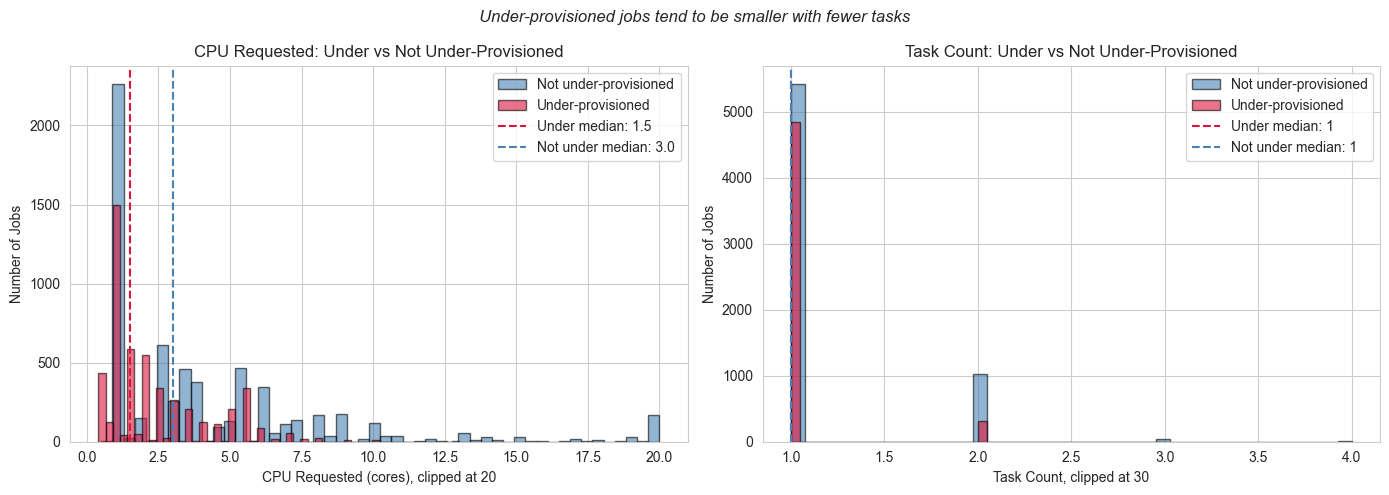

In [30]:
under_df     = merged_clean[merged_clean['is_underprovision'] == 1].copy()
not_under_df = merged_clean[merged_clean['is_underprovision'] == 0].copy()

print(f"Under-provisioned jobs : {len(under_df):,}")
print(f"Not under-provisioned  : {len(not_under_df):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(not_under_df['plan_cpu_cores'].clip(upper=20),
             bins=50, alpha=0.6, color='steelblue', edgecolor='black',
             label='Not under-provisioned')
axes[0].hist(under_df['plan_cpu_cores'].clip(upper=20),
             bins=50, alpha=0.6, color='crimson', edgecolor='black',
             label='Under-provisioned')
axes[0].axvline(under_df['plan_cpu_cores'].median(), color='crimson',
                linestyle='--', linewidth=1.5,
                label=f"Under median: {under_df['plan_cpu_cores'].median():.1f}")
axes[0].axvline(not_under_df['plan_cpu_cores'].median(), color='steelblue',
                linestyle='--', linewidth=1.5,
                label=f"Not under median: {not_under_df['plan_cpu_cores'].median():.1f}")
axes[0].set_xlabel('CPU Requested (cores), clipped at 20')
axes[0].set_ylabel('Number of Jobs')
axes[0].set_title('CPU Requested: Under vs Not Under-Provisioned')
axes[0].legend()

axes[1].hist(not_under_df['task_count'].clip(upper=30),
             bins=40, alpha=0.6, color='steelblue', edgecolor='black',
             label='Not under-provisioned')
axes[1].hist(under_df['task_count'].clip(upper=30),
             bins=40, alpha=0.6, color='crimson', edgecolor='black',
             label='Under-provisioned')
axes[1].axvline(under_df['task_count'].median(), color='crimson',
                linestyle='--', linewidth=1.5,
                label=f"Under median: {under_df['task_count'].median():.0f}")
axes[1].axvline(not_under_df['task_count'].median(), color='steelblue',
                linestyle='--', linewidth=1.5,
                label=f"Not under median: {not_under_df['task_count'].median():.0f}")
axes[1].set_xlabel('Task Count, clipped at 30')
axes[1].set_ylabel('Number of Jobs')
axes[1].set_title('Task Count: Under vs Not Under-Provisioned')
axes[1].legend()

plt.suptitle('Under-provisioned jobs tend to be smaller with fewer tasks',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

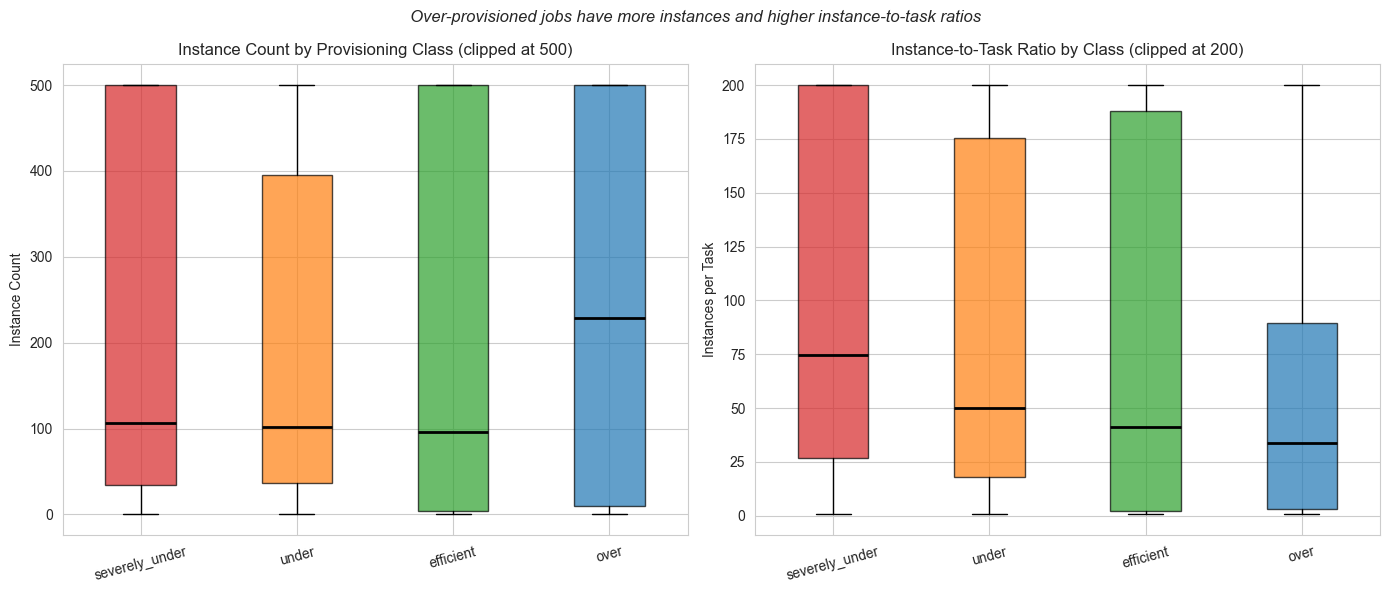

Median instance_count by class:
  severely_under      : 106
  under               : 102
  efficient           : 96
  over                : 229

Median instance_to_task_ratio by class:
  severely_under      : 74.50
  under               : 50.00
  efficient           : 41.00
  over                : 33.67


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

class_order = ['severely_under', 'under', 'efficient', 'over']
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

plot_data_instance = [
    merged_clean[merged_clean['provisioning_class'] == cls]['instance_count'].clip(upper=500)
    for cls in class_order
]

bp1 = axes[0].boxplot(plot_data_instance, labels=class_order,
                      patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_title('Instance Count by Provisioning Class (clipped at 500)')
axes[0].set_ylabel('Instance Count')
axes[0].tick_params(axis='x', rotation=15)

plot_data_ratio = [
    merged_clean[merged_clean['provisioning_class'] == cls]['instance_to_task_ratio'].clip(upper=200)
    for cls in class_order
]

bp2 = axes[1].boxplot(plot_data_ratio, labels=class_order,
                      patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Instance-to-Task Ratio by Class (clipped at 200)')
axes[1].set_ylabel('Instances per Task')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Over-provisioned jobs have more instances and higher instance-to-task ratios',
             fontsize=12, style='italic')
plt.tight_layout()
plt.show()

print("Median instance_count by class:")
for cls in class_order:
    med = merged_clean[merged_clean['provisioning_class'] == cls]['instance_count'].median()
    print(f"  {cls:<20}: {med:.0f}")

print("\nMedian instance_to_task_ratio by class:")
for cls in class_order:
    med = merged_clean[merged_clean['provisioning_class'] == cls]['instance_to_task_ratio'].median()
    print(f"  {cls:<20}: {med:.2f}")

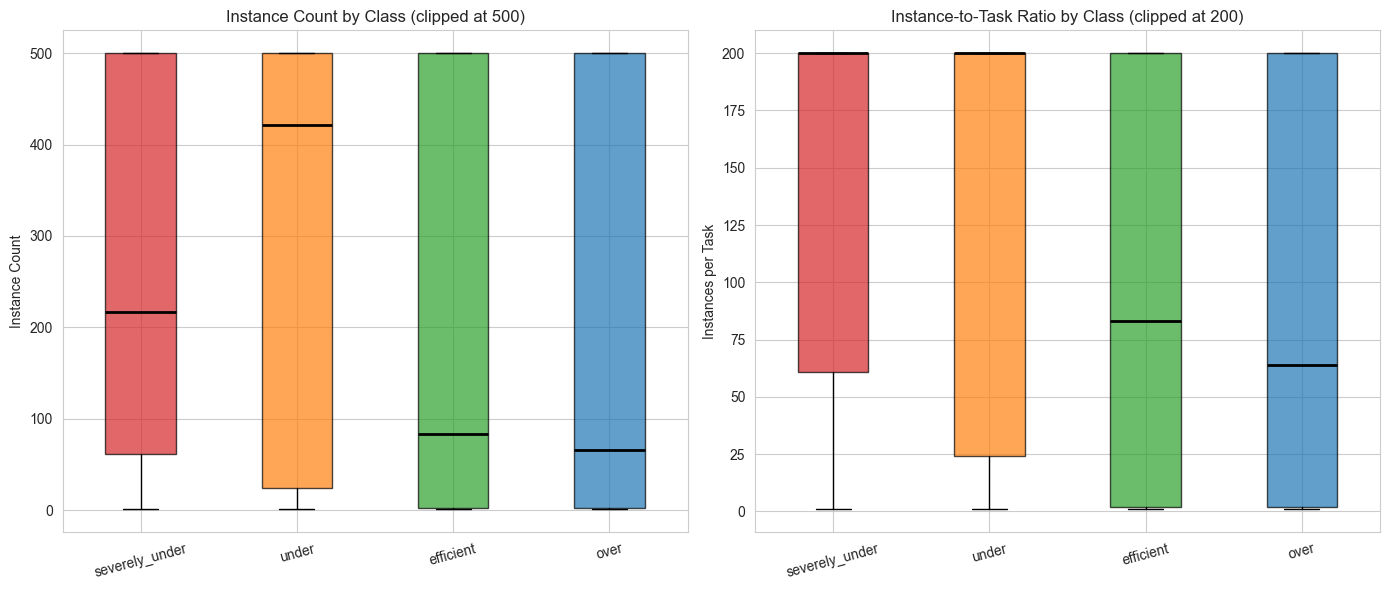

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

class_order = ['severely_under', 'under', 'efficient', 'over']
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

bp1 = axes[0].boxplot(
    [merged_clean[merged_clean['provisioning_class'] == cls]['instance_count'].clip(upper=500)
     for cls in class_order],
    labels=class_order, patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Instance Count by Class (clipped at 500)')
axes[0].set_ylabel('Instance Count')
axes[0].tick_params(axis='x', rotation=15)

bp2 = axes[1].boxplot(
    [merged_clean[merged_clean['provisioning_class'] == cls]['instance_to_task_ratio'].clip(upper=200)
     for cls in class_order],
    labels=class_order, patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Instance-to-Task Ratio by Class (clipped at 200)')
axes[1].set_ylabel('Instances per Task')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

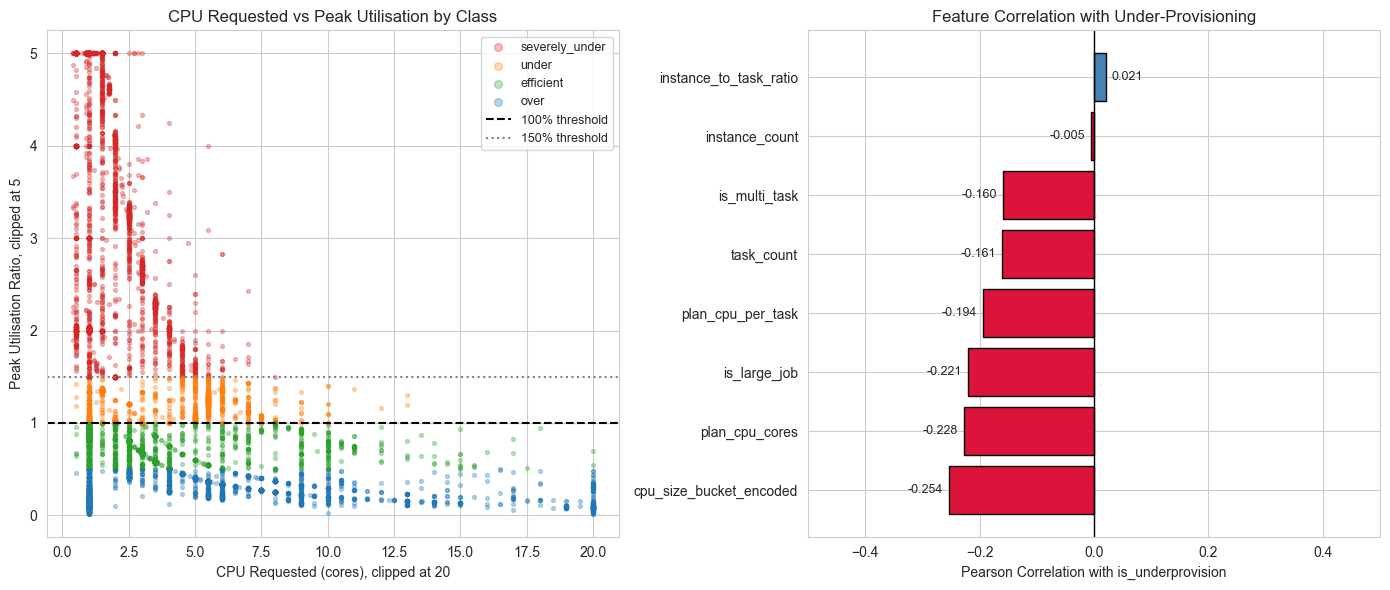

Feature correlations with is_underprovision:
cpu_size_bucket_encoded   -0.254338
plan_cpu_cores            -0.228062
is_large_job              -0.220820
plan_cpu_per_task         -0.194132
task_count                -0.160583
is_multi_task             -0.159720
instance_count            -0.005336
instance_to_task_ratio     0.021348


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

class_colors = {
    'severely_under': '#d62728',
    'under':          '#ff7f0e',
    'efficient':      '#2ca02c',
    'over':           '#1f77b4'
}

for cls, color in class_colors.items():
    subset = merged_clean[merged_clean['provisioning_class'] == cls]
    axes[0].scatter(subset['plan_cpu_cores'].clip(upper=20),
                    subset['util_ratio_peak'].clip(upper=5),
                    alpha=0.3, s=8, color=color, label=cls)

axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='100% threshold')
axes[0].axhline(1.5, color='grey',  linestyle=':',  linewidth=1.5, label='150% threshold')
axes[0].set_xlabel('CPU Requested (cores), clipped at 20')
axes[0].set_ylabel('Peak Utilisation Ratio, clipped at 5')
axes[0].set_title('CPU Requested vs Peak Utilisation by Class')
axes[0].legend(markerscale=2, fontsize=9)

correlations = merged_clean[FEATURES + ['is_underprovision']].corr()['is_underprovision'].drop('is_underprovision')
correlations_sorted = correlations.sort_values()

axes[1].barh(correlations_sorted.index, correlations_sorted.values,
             color=['crimson' if c < 0 else 'steelblue' for c in correlations_sorted],
             edgecolor='black')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Pearson Correlation with is_underprovision')
axes[1].set_title('Feature Correlation with Under-Provisioning')
axes[1].set_xlim(-0.5, 0.5)

for i, val in enumerate(correlations_sorted.values):
    axes[1].text(
        val + (0.01 if val >= 0 else -0.01), i,
        f'{val:.3f}', va='center',
        ha='left' if val >= 0 else 'right', fontsize=9
    )

plt.tight_layout()
plt.show()

print("Feature correlations with is_underprovision:")
print(correlations_sorted.to_string())

---
### Deep Dive Observations

1. Small CPU request — median 1.0 core vs 2.5 cores for not under-provisioned jobs. Nearly all under-provisioned jobs request 2 cores or fewer.

2. Few tasks — median 2 tasks vs 5 tasks for not under-provisioned jobs. Single-task jobs are the highest risk group.

3. Low CPU per task — the strongest correlation after size bucket (-0.24).

4. Instance count and instance-to-task ratio are noisy features with near-zero correlation to the target.

**Key finding:** Under-provisioning is essentially a small-job phenomenon.

In [33]:
X = merged_clean[FEATURES].copy()
y = merged_clean['is_underprovision'].copy()

print("=" * 60)
print("SECTION 4: TRAIN/TEST SPLIT")
print("=" * 60)
print(f"\nFeature matrix shape: {X.shape}")
print(f"Class balance: {y.mean()*100:.1f}% under-provisioned")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")
print(f"\nTrain — Under: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Test  — Under: {y_test.sum():,}  ({y_test.mean()*100:.1f}%)")
print("\nStratified split confirmed")

SECTION 4: TRAIN/TEST SPLIT

Feature matrix shape: (11644, 8)
Class balance: 44.2% under-provisioned

Train size: 9,315
Test size:  2,329

Train — Under: 4,119 (44.2%)
Test  — Under: 1,030  (44.2%)

Stratified split confirmed


---
## Section 5: Baseline Model — Logistic Regression

SECTION 5: LOGISTIC REGRESSION
               precision    recall  f1-score   support

Not Under (0)       0.76      0.47      0.58      1299
    Under (1)       0.55      0.82      0.66      1030

     accuracy                           0.62      2329
    macro avg       0.66      0.64      0.62      2329
 weighted avg       0.67      0.62      0.61      2329

ROC-AUC: 0.7421


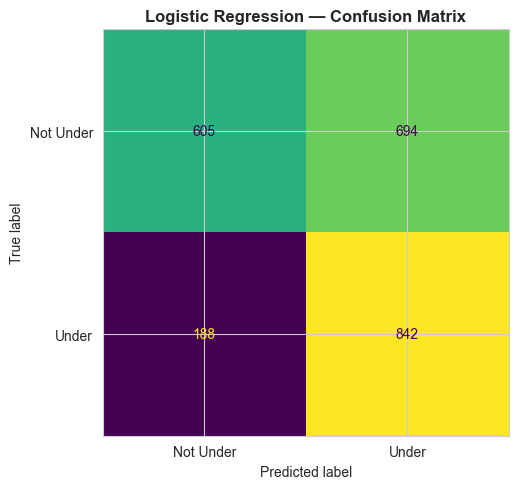

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("SECTION 5: LOGISTIC REGRESSION")
print("=" * 60)
print(classification_report(y_test, y_pred_lr, target_names=['Not Under (0)', 'Under (1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=['Not Under', 'Under']).plot(ax=ax, colorbar=False)
ax.set_title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 6: Main Model — Random Forest

SECTION 6: RANDOM FOREST
               precision    recall  f1-score   support

Not Under (0)       0.84      0.86      0.85      1299
    Under (1)       0.82      0.79      0.80      1030

     accuracy                           0.83      2329
    macro avg       0.83      0.82      0.83      2329
 weighted avg       0.83      0.83      0.83      2329

ROC-AUC: 0.9078


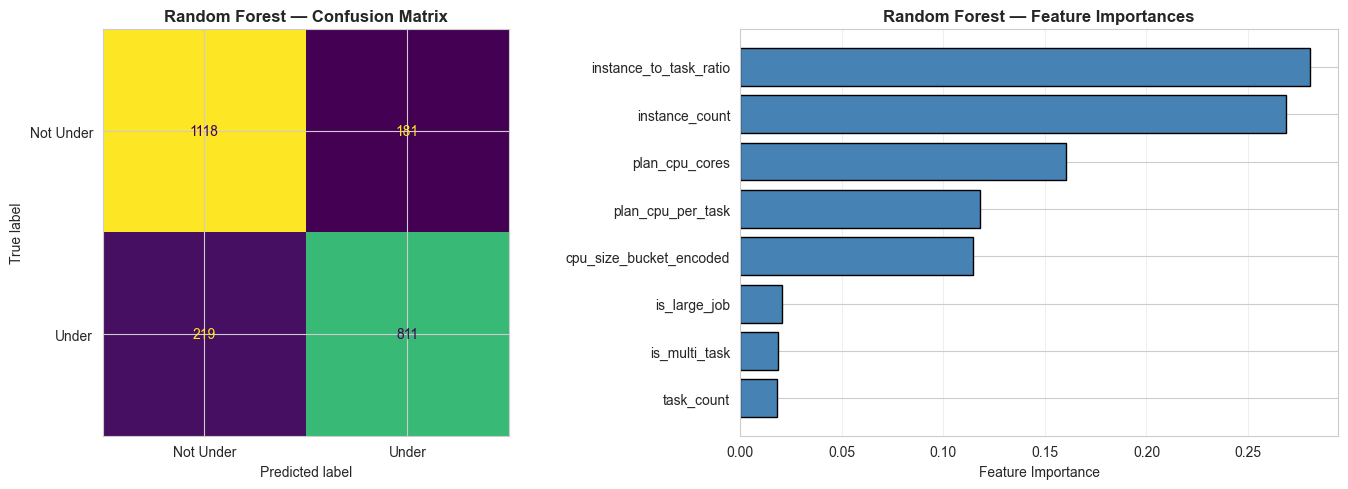


Feature importances:
  task_count                    : 0.0184
  is_multi_task                 : 0.0187
  is_large_job                  : 0.0209
  cpu_size_bucket_encoded       : 0.1146
  plan_cpu_per_task             : 0.1182
  plan_cpu_cores                : 0.1603
  instance_count                : 0.2686
  instance_to_task_ratio        : 0.2802


In [35]:
rf = RandomForestClassifier(
    class_weight='balanced', n_estimators=100, random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print("=" * 60)
print("SECTION 6: RANDOM FOREST")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=['Not Under (0)', 'Under (1)']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=['Not Under', 'Under']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Random Forest — Confusion Matrix', fontweight='bold')

importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
axes[1].barh(importances.index, importances.values, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Random Forest — Feature Importances', fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nFeature importances:")
for feat, imp in importances.items():
    print(f"  {feat:<30}: {imp:.4f}")

---
## Section 7: Error Analysis

SECTION 7: ERROR ANALYSIS

False Negatives (missed under-provisioned): 219
True Positives  (caught under-provisioned): 811

False Negatives by size bucket:
size_bucket
Small (0.5-1)    98
Large (2-5)      71
XLarge (5-10)    35
Medium (1-2)     14
Tiny (0-0.5)      1
Huge (10+)        0

True Positives by size bucket:
size_bucket
Medium (1-2)     232
Small (0.5-1)    231
Large (2-5)      182
Tiny (0-0.5)      87
XLarge (5-10)     79
Huge (10+)         0


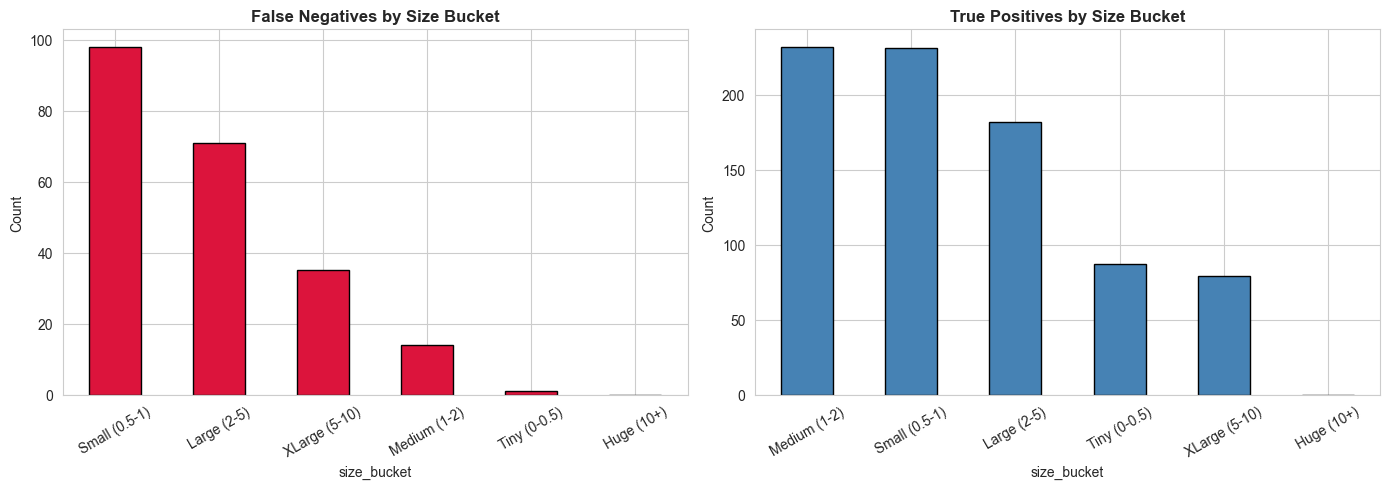

In [36]:
print("=" * 60)
print("SECTION 7: ERROR ANALYSIS")
print("=" * 60)

X_test_copy = X_test.copy()
X_test_copy['actual']    = y_test.values
X_test_copy['predicted'] = y_pred_rf
X_test_copy['size_bucket'] = merged_clean.loc[X_test.index, 'size_bucket'].values

false_negatives = X_test_copy[(X_test_copy['actual'] == 1) & (X_test_copy['predicted'] == 0)]
true_positives  = X_test_copy[(X_test_copy['actual'] == 1) & (X_test_copy['predicted'] == 1)]

print(f"\nFalse Negatives (missed under-provisioned): {len(false_negatives):,}")
print(f"True Positives  (caught under-provisioned): {len(true_positives):,}")

print("\nFalse Negatives by size bucket:")
print(false_negatives['size_bucket'].value_counts().to_string())

print("\nTrue Positives by size bucket:")
print(true_positives['size_bucket'].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
false_negatives['size_bucket'].value_counts().plot(
    kind='bar', ax=axes[0], color='crimson', edgecolor='black')
axes[0].set_title('False Negatives by Size Bucket', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

true_positives['size_bucket'].value_counts().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('True Positives by Size Bucket', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## Section 8: Correction Factor & Recommendation Engine

In [40]:
print("=" * 60)
print("SECTION 8: RECOMMENDATION ENGINE")
print("=" * 60)

full_set = merged_clean.copy()
full_set['predicted_class'] = rf.predict(full_set[FEATURES])

under_mask = full_set['predicted_class'] == 1

# Under-provisioned: scale up by actual utilisation ratio + 10% safety buffer
# Not under-provisioned: keep plan_cpu_cores (no change needed)
full_set['recommended_cpu'] = np.where(
    under_mask,
    full_set['plan_cpu_cores'] * full_set['util_ratio_peak'] * 1.10,
    full_set['plan_cpu_cores']
)

# Floor: recommended must never be less than actual peak observed
full_set['recommended_cpu'] = full_set[['recommended_cpu', 'cpu_max_peak']].max(axis=1)

summary = full_set.groupby('predicted_class').agg(
    job_count=('plan_cpu_cores', 'count'),
    avg_requested=('plan_cpu_cores', 'mean'),
    avg_recommended=('recommended_cpu', 'mean'),
    avg_actual_peak=('cpu_max_peak', 'mean')
).reset_index()

summary['predicted_class'] = summary['predicted_class'].map(
    {1: 'Under-provisioned', 0: 'Not Under-provisioned'})

print("\nRecommendation Summary by Predicted Class:")
print(summary.to_string(index=False))

baseline_total    = full_set['plan_cpu_cores'].sum()
recommended_total = full_set['recommended_cpu'].sum()
net_change        = recommended_total - baseline_total

print(f"\nTotal baseline allocation : {baseline_total:>12,.2f} cores")
print(f"Total recommended alloc.  : {recommended_total:>12,.2f} cores")
print(f"Net change                : {net_change:>12,.2f} cores ({net_change/baseline_total*100:.1f}%)")

if net_change < 0:
    print(f"\nNet saving: {abs(net_change):,.0f} cores ({abs(net_change)/baseline_total*100:.1f}%)")
else:
    print(f"\nNet increase: {net_change:,.0f} cores — under-provisioned jobs corrected upward")

SECTION 8: RECOMMENDATION ENGINE

Recommendation Summary by Predicted Class:
      predicted_class  job_count  avg_requested  avg_recommended  avg_actual_peak
Not Under-provisioned       6581       4.537707         4.696127         1.988886
    Under-provisioned       5063       2.442129         5.452732         4.957029

Total baseline allocation :    42,227.15 cores
Total recommended alloc.  :    58,512.39 cores
Net change                :    16,285.24 cores (38.6%)

Net increase: 16,285 cores — under-provisioned jobs corrected upward


---
## Section 9: Final Summary

In [41]:
print("=" * 70)
print("STAGE 1B COMPLETE — REPORTABLE FINDINGS")
print("=" * 70)

report_lr = classification_report(y_test, y_pred_lr,
                                   target_names=['Not Under', 'Under'],
                                   output_dict=True)
report_rf = classification_report(y_test, y_pred_rf,
                                   target_names=['Not Under', 'Under'],
                                   output_dict=True)

print("\nModel Performance Summary:")
print(f"{'Metric':<30} {'Logistic Reg':>15} {'Random Forest':>15}")
print(f"{'-'*60}")
print(f"{'Recall (Under class)':<30} {report_lr['Under']['recall']:>15.3f} {report_rf['Under']['recall']:>15.3f}")
print(f"{'Precision (Under class)':<30} {report_lr['Under']['precision']:>15.3f} {report_rf['Under']['precision']:>15.3f}")
print(f"{'F1 (Under class)':<30} {report_lr['Under']['f1-score']:>15.3f} {report_rf['Under']['f1-score']:>15.3f}")
print(f"{'ROC-AUC':<30} {roc_auc_score(y_test, y_prob_lr):>15.3f} {roc_auc_score(y_test, y_prob_rf):>15.3f}")

print(f"\nProvisioning Class Distribution:")
for cls in ['severely_under', 'under', 'efficient', 'over']:
    count = (merged_clean['provisioning_class'] == cls).sum()
    print(f"  {cls:<20}: {count:>6,} ({count/total*100:.1f}%)")

print(f"\nRecommendation Engine — Net Effect:")
print(f"  Baseline total  : {baseline_total:>10,.0f} cores")
print(f"  Recommended     : {recommended_total:>10,.0f} cores")
print(f"  Net change      : {net_change:>10,.0f} cores ({net_change/baseline_total*100:.1f}%)")

print("\nStage 1b Complete")
print("   Classifier: Random Forest with class_weight='balanced'")
print("   Primary metric: Recall on under-provisioned class")
print("   Stage 2 will extend this with LSTM-based time-series prediction")

STAGE 1B COMPLETE — REPORTABLE FINDINGS

Model Performance Summary:
Metric                            Logistic Reg   Random Forest
------------------------------------------------------------
Recall (Under class)                     0.817           0.787
Precision (Under class)                  0.548           0.818
F1 (Under class)                         0.656           0.802
ROC-AUC                                  0.742           0.908

Provisioning Class Distribution:
  severely_under      :  3,225 (27.7%)
  under               :  1,924 (16.5%)
  efficient           :  3,206 (27.5%)
  over                :  3,289 (28.2%)

Recommendation Engine — Net Effect:
  Baseline total  :     42,227 cores
  Recommended     :     58,512 cores
  Net change      :     16,285 cores (38.6%)

Stage 1b Complete
   Classifier: Random Forest with class_weight='balanced'
   Primary metric: Recall on under-provisioned class
   Stage 2 will extend this with LSTM-based time-series prediction


In [42]:
print(merged_clean['plan_cpu_cores'].describe())
print(merged_clean['cpu_max_peak'].describe())
print(merged_clean['util_ratio_peak'].describe())

count    11644.000000
mean         3.626516
std          5.092765
min          0.400000
25%          1.000000
50%          2.500000
75%          5.000000
max        156.000000
Name: plan_cpu_cores, dtype: float64
count    11644.000000
mean         3.279483
std          2.968821
min          0.020000
25%          1.050000
50%          2.030000
75%          5.332500
max         31.000000
Name: cpu_max_peak, dtype: float64
count    11644.000000
mean         1.624799
std          2.343218
min          0.019231
25%          0.412000
50%          0.868486
75%          1.790278
max         31.000000
Name: util_ratio_peak, dtype: float64


In [43]:
print("Jobs using MORE than requested (util_ratio_peak > 1.0):")
over_requested = (merged_clean['util_ratio_peak'] > 1.0).sum()
print(f"  Count: {over_requested:,} ({over_requested/len(merged_clean)*100:.1f}%)")

print("\nExample — severely under-provisioned job:")
print(merged_clean[merged_clean['provisioning_class'] == 'severely_under'][
    ['plan_cpu_cores', 'cpu_max_peak', 'util_ratio_peak']
].head(3))

print("\nExample — efficient job:")
print(merged_clean[merged_clean['provisioning_class'] == 'efficient'][
    ['plan_cpu_cores', 'cpu_max_peak', 'util_ratio_peak']
].head(3))

Jobs using MORE than requested (util_ratio_peak > 1.0):
  Count: 4,673 (40.1%)

Example — severely under-provisioned job:
   plan_cpu_cores  cpu_max_peak  util_ratio_peak
0             1.0           2.0              2.0
1             1.0           3.0              3.0
2             1.0           3.0              3.0

Example — efficient job:
    plan_cpu_cores  cpu_max_peak  util_ratio_peak
4              1.0          0.79             0.79
5              5.0          3.00             0.60
12             1.0          0.96             0.96


In [39]:
# Save outputs for Stage 2
import json

PROCESSED_DIR = Path('/Users/prarthanagovindaraj/Desktop/Cloud_Resource_Optimisation_thesis/data/processed')

# 1. Save the full merged_clean with all features and labels
merged_clean.to_csv(PROCESSED_DIR / 'stage1b_merged_clean.csv', index=False)
print(f"Saved stage1b_merged_clean.csv: {merged_clean.shape}")

# 2. Save under-provisioned jobs only
under_jobs = merged_clean[merged_clean['is_underprovision'] == 1].copy()
under_jobs.to_csv(PROCESSED_DIR / 'stage1b_under_provisioned.csv', index=False)
print(f"Saved stage1b_under_provisioned.csv: {under_jobs.shape}")

# 3. Save model performance summary as JSON
import sklearn
from sklearn.metrics import roc_auc_score, classification_report

report_rf = classification_report(y_test, y_pred_rf,
                                   target_names=['Not Under', 'Under'],
                                   output_dict=True)

summary = {
    'total_jobs': int(len(merged_clean)),
    'under_provisioned_count': int(merged_clean['is_underprovision'].sum()),
    'under_provisioned_pct': float(merged_clean['is_underprovision'].mean() * 100),
    'rf_recall_under': float(report_rf['Under']['recall']),
    'rf_precision_under': float(report_rf['Under']['precision']),
    'rf_f1_under': float(report_rf['Under']['f1-score']),
    'rf_roc_auc': float(roc_auc_score(y_test, y_prob_rf)),
    'class_distribution': {
        cls: int((merged_clean['provisioning_class'] == cls).sum())
        for cls in ['severely_under', 'under', 'efficient', 'over']
    },
    'features_used': FEATURES
}

with open(PROCESSED_DIR / 'stage1b_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f"Saved stage1b_summary.json")

print("\nAll Stage 1b outputs saved. Ready for Stage 2.")

Saved stage1b_merged_clean.csv: (11644, 19)
Saved stage1b_under_provisioned.csv: (5149, 19)
Saved stage1b_summary.json

All Stage 1b outputs saved. Ready for Stage 2.
